In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_theme(style="whitegrid")

# 1. EXACT WINDOWS PATHS (Adjust if your folder structure is slightly different)
DATASETS_DIR = r"C:\AAA FACULTA\LICENTA\Wind Farm A\datasets"
EVENT_INFO_PATH = r"C:\AAA FACULTA\LICENTA\Wind Farm A\comma_event_info.csv"

# 2. Load Event Labels
event_info = pd.read_csv(EVENT_INFO_PATH)
event_info['event_start'] = pd.to_datetime(event_info['event_start'])
event_info['event_end'] = pd.to_datetime(event_info['event_end'])

# 3. Load Datasets
all_datasets = {}
print("Loading datasets...")
for filename in os.listdir(DATASETS_DIR):
    if filename.startswith('comma_') and filename.endswith('.csv'):
        file_path = os.path.join(DATASETS_DIR, filename)
        event_id = int(filename.split('.')[0].replace('comma_', '')) 
        
        df = pd.read_csv(file_path)
        df['event_id'] = event_id
        all_datasets[event_id] = df

print(f"✅ Successfully loaded {len(all_datasets)} datasets.")

# 4. Define Sensor List
ignore_cols = ['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id', 'event_id']
all_sensors = [col for col in all_datasets[0].columns if col not in ignore_cols]
print(f"✅ Identified {len(all_sensors)} sensor columns.")

Loading datasets...
✅ Successfully loaded 22 datasets.
✅ Identified 81 sensor columns.


In [3]:
from sklearn.ensemble import RandomForestRegressor

MAX_RUL_HOURS = 72
MAX_RUL_ROWS = MAX_RUL_HOURS * 6 # 6 rows per hour (10 min intervals)

print("1. Applying Interpolation, Outlier Clipping, and RUL calculation...")
for eid, df in all_datasets.items():
    df['time_stamp'] = pd.to_datetime(df['time_stamp'])
    
    # Smooth interpolation for missing data (ONLY on numeric sensors)
    df[all_sensors] = df[all_sensors].interpolate(method='linear', limit=6).bfill()
    
    # Winsorization (Clip extreme 1% outliers)
    for col in all_sensors:
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        df[col] = df[col].clip(lower, upper)
        
    # Calculate Remaining Useful Life (RUL)
    df['RUL'] = MAX_RUL_ROWS 
    is_anomaly = (event_info[event_info['event_id']==eid]['event_label'].iloc[0] == 'anomaly')
    
    if is_anomaly:
        start_time = event_info[event_info['event_id']==eid]['event_start'].iloc[0]
        failure_idx = df[df['time_stamp'] >= start_time].index.min()
        
        if pd.notna(failure_idx):
            df.loc[:failure_idx, 'RUL'] = failure_idx - df.loc[:failure_idx].index
            
    df['RUL'] = df['RUL'].clip(upper=MAX_RUL_ROWS)
    all_datasets[eid] = df

print("2. Training Random Forest to find Top 15 Features...")
train_data = pd.concat([d[d['train_test']=='train'] for d in all_datasets.values()])
valid_train_data = train_data[train_data['status_type_id'].isin([0, 1, 2, 5])].dropna()
sample_data = valid_train_data.sample(frac=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(sample_data[all_sensors], sample_data['RUL'])

feature_importances = pd.Series(rf.feature_importances_, index=all_sensors).sort_values(ascending=False)
top_15_rf_sensors = feature_importances.head(15).index.tolist()

print("\n✅ Top 5 sensors driving the failures:")
print(feature_importances.head(5))

1. Applying Interpolation, Outlier Clipping, and RUL calculation...
2. Training Random Forest to find Top 15 Features...

✅ Top 5 sensors driving the failures:
sensor_2_avg     0.065469
sensor_42_avg    0.057340
sensor_43_avg    0.053168
sensor_12_avg    0.050195
power_30_std     0.044291
dtype: float64


In [4]:
from sklearn.preprocessing import RobustScaler

def generate_rul_sequences(sensor_list, lookback_rows=72, stride=3):
    X_train, y_train, X_test, y_test = [], [], [], []
    
    # Fit scaler ONLY on train data
    train_data = pd.concat([d[d['train_test']=='train'] for d in all_datasets.values()])
    scaler = RobustScaler()
    scaler.fit(train_data[sensor_list])
    
    for eid, df in all_datasets.items():
        valid_df = df[df['status_type_id'].isin([0, 1, 2, 5])].copy()
        if len(valid_df) <= lookback_rows:
            continue
            
        scaled_features = scaler.transform(valid_df[sensor_list])
        targets = valid_df['RUL'].values
        splits = valid_df['train_test'].values
        
        # Sliding window with Stride
        for i in range(0, len(valid_df) - lookback_rows, stride):
            seq_x = scaled_features[i : i + lookback_rows]
            seq_y = targets[i + lookback_rows] 
            seq_split = splits[i + lookback_rows]
            
            if seq_split == 'train':
                X_train.append(seq_x)
                y_train.append(seq_y)
            else:
                X_test.append(seq_x)
                y_test.append(seq_y)
                
    return np.array(X_train), np.array(y_train), np.array(X_test), np.array(y_test)

print("Generating 3D Sequences for the Neural Network...")
X_tr, y_tr, X_te, y_te = generate_rul_sequences(top_15_rf_sensors, lookback_rows=72, stride=3)

print(f"✅ Training data shape: {X_tr.shape}")
print(f"✅ Testing data shape: {X_te.shape}")

Generating 3D Sequences for the Neural Network...
✅ Training data shape: (370952, 72, 15)
✅ Testing data shape: (14883, 72, 15)


In [5]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, Dropout

# 1. Build the Architecture
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_tr.shape[1], X_tr.shape[2])),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    
    Dense(32, activation='relu'),
    Dense(1, activation='linear') # Outputs a continuous number (RUL)
])

# 2. Compile using Huber loss
model.compile(optimizer='adam', loss=tf.keras.losses.Huber(), metrics=['mae'])

print("Training the Remaining Useful Life (RUL) Model...")
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 3. Train
history = model.fit(
    X_tr, y_tr, 
    validation_data=(X_te, y_te), 
    epochs=30, 
    batch_size=128, 
    callbacks=[early_stop], 
    verbose=1
)

# 4. Evaluate
test_loss, test_mae = model.evaluate(X_te, y_te, verbose=0)
mae_hours = test_mae / 6 # Convert rows back to hours

print(f"\n✅ Final Test Mean Absolute Error: {mae_hours:.2f} hours")
print(f"Meaning: When predicting a failure up to 3 days out, the model is off by an average of {mae_hours:.2f} hours.")

c:\AAA FACULTA\LICENTA\wf_pm_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training the Remaining Useful Life (RUL) Model...
Epoch 1/30
2899/2899 ━━━━━━━━━━━━━━━━━━━━ 60s 20ms/step - loss: 51.6746 - mae: 52.1724 - val_loss: 10.8681 - val_mae: 11.3681
Epoch 2/30
2899/2899 ━━━━━━━━━━━━━━━━━━━━ 54s 19ms/step - loss: 19.9441 - mae: 20.4401 - val_loss: 13.3989 - val_mae: 13.8989
Epoch 3/30
2899/2899 ━━━━━━━━━━━━━━━━━━━━ 55s 19ms/step - loss: 18.2947 - mae: 18.7897 - val_loss: 10.9559 - val_mae: 11.4559
Epoch 4/30
2899/2899 ━━━━━━━━━━━━━━━━━━━━ 54s 19ms/step - loss: 16.0660 - mae: 16.5606 - val_loss: 12.2501 - val_mae: 12.7500
Epoch 5/30
2899/2899 ━━━━━━━━━━━━━━━━━━━━ 55s 19ms/step - loss: 12.8969 - mae: 13.3899 - val_loss: 11.5115 - val_mae: 12.0115
Epoch 6/30
2899/2899 ━━━━━━━━━━━━━━━━━━━━ 55s 19ms/step - loss: 8.3482 - mae: 8.8355 - val_loss: 9.6996 - val_mae: 10.1973
Epoch 7/30
2899/2899 ━━━━━━━━━━━━━━━━━━━━ 55s 19ms/step - loss: 2.5392 - mae: 2.9437 - val_loss: 9.1430 - val_mae: 9.2227
Epoch 8/30
2899/2899 ━━━━━━━━━━━━━━━━━━━━ 55s 19ms/step - loss: 0.3898 - ma

Extracting sequences for Strict 50/50 Balancing...
Found 1149 Failing Sequences in training data.
Final Balanced Training Data: 2298 sequences (Exactly 50% healthy, 50% failing).
Retraining Model with Mean Squared Error (MSE)...
Epoch 1/30


c:\AAA FACULTA\LICENTA\wf_pm_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 128664.0625 - mae: 334.9273
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 123895.4922 - mae: 328.1585
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 116724.7656 - mae: 317.8994
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 107090.2578 - mae: 303.7532
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 95244.5312 - mae: 285.4543
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 81254.9375 - mae: 260.8089
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 66487.0000 - mae: 231.7838
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 49481.1133 - mae: 196.7959
Epoch 9/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 39425.1680 - mae: 164.8908
Epoch 10/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 27877.6699 - mae: 141.1605
Epoch 11/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 23025.9023 - mae: 137.2516
Epoch 12/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss:

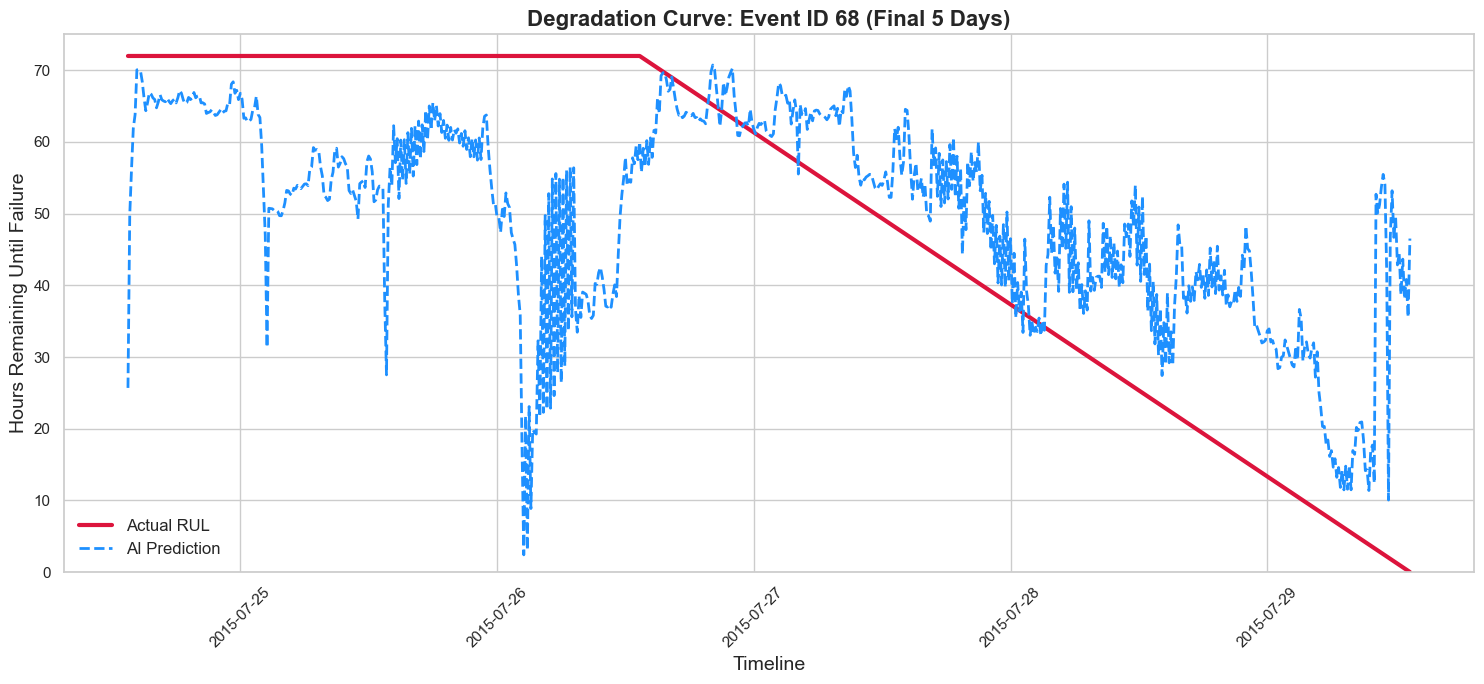

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.utils import shuffle
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, Dropout, BatchNormalization

# ==========================================
# 1. STRICT 50/50 DATA BALANCING
# ==========================================
print("Extracting sequences for Strict 50/50 Balancing...")

healthy_seqs, healthy_targets = [], []
failing_seqs, failing_targets = [], []

train_data = pd.concat([d[d['train_test']=='train'] for d in all_datasets.values()])
scaler = RobustScaler()
scaler.fit(train_data[top_15_rf_sensors])

for eid, df in all_datasets.items():
    valid_df = df[df['status_type_id'].isin([0, 1, 2, 5])].copy()
    if len(valid_df) <= 72:
        continue
        
    scaled_features = scaler.transform(valid_df[top_15_rf_sensors])
    targets = valid_df['RUL'].values
    splits = valid_df['train_test'].values
    
    # We only care about balancing the TRAINING data
    for i in range(0, len(valid_df) - 72, 2): # Stride = 2 for slightly more data
        seq_x = scaled_features[i : i + 72]
        seq_y = targets[i + 72] 
        seq_split = splits[i + 72]
        
        if seq_split == 'train':
            if seq_y == MAX_RUL_ROWS:
                healthy_seqs.append(seq_x)
                healthy_targets.append(seq_y)
            else:
                failing_seqs.append(seq_x)
                failing_targets.append(seq_y)

# Force the 50/50 Split
min_count = len(failing_seqs) # Find out exactly how many failing sequences we have
print(f"Found {min_count} Failing Sequences in training data.")

# Randomly select the exact same number of healthy sequences
import random
indices = random.sample(range(len(healthy_seqs)), min_count)
balanced_healthy_seqs = [healthy_seqs[i] for i in indices]
balanced_healthy_targets = [healthy_targets[i] for i in indices]

# Combine and Shuffle so the AI doesn't memorize the order
X_tr = np.array(balanced_healthy_seqs + failing_seqs)
y_tr = np.array(balanced_healthy_targets + failing_targets)
X_tr, y_tr = shuffle(X_tr, y_tr, random_state=42)

print(f"Final Balanced Training Data: {len(X_tr)} sequences (Exactly 50% healthy, 50% failing).")

# ==========================================
# 2. AGGRESSIVE RETRAINING
# ==========================================
print("Retraining Model with Mean Squared Error (MSE)...")
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_tr.shape[1], X_tr.shape[2])),
    BatchNormalization(), # Added Batch Normalization to force the network to pay attention to spikes
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

# Switching to MSE to severely punish the AI for flatlining
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
early_stop = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

# Train the model
model.fit(X_tr, y_tr, epochs=30, batch_size=64, callbacks=[early_stop], verbose=1)

# ==========================================
# 3. VISUALIZE THE TARGET FAILURE
# ==========================================
anomaly_ids = event_info[event_info['event_label'] == 'anomaly']['event_id'].tolist()
target_event_id = anomaly_ids[0] 

df_target = all_datasets[target_event_id]
df_valid = df_target[df_target['status_type_id'].isin([0, 1, 2, 5])].copy()

failure_time = event_info[event_info['event_id']==target_event_id]['event_start'].iloc[0]
df_valid = df_valid[df_valid['time_stamp'] <= failure_time]

scaled_features = scaler.transform(df_valid[top_15_rf_sensors])
targets = df_valid['RUL'].values
timestamps = df_valid['time_stamp'].values

X_viz, y_viz, time_viz = [], [], []
for i in range(len(df_valid) - 72):
    X_viz.append(scaled_features[i : i + 72])
    y_viz.append(targets[i + 72])
    time_viz.append(timestamps[i + 72])
    
X_viz, y_viz = np.array(X_viz), np.array(y_viz)
predictions = model.predict(X_viz, verbose=0).flatten()

y_viz_hours = y_viz / 6
pred_hours = predictions / 6

zoom_rows = 720
if len(y_viz_hours) > zoom_rows:
    y_viz_hours = y_viz_hours[-zoom_rows:]
    pred_hours = pred_hours[-zoom_rows:]
    time_viz = time_viz[-zoom_rows:]

plt.figure(figsize=(15, 7))
plt.plot(time_viz, y_viz_hours, label='Actual RUL', color='crimson', linewidth=3)
plt.plot(time_viz, pred_hours, label='AI Prediction', color='dodgerblue', linestyle='--', linewidth=2)

plt.title(f"Degradation Curve: Event ID {target_event_id} (Final 5 Days)", fontsize=16, fontweight='bold')
plt.ylabel("Hours Remaining Until Failure", fontsize=14)
plt.xlabel("Timeline", fontsize=14)
plt.ylim(0, 75)
plt.xticks(rotation=45)
plt.legend(fontsize=12, loc='lower left')
plt.tight_layout()
plt.show()